Decision Tree Analysis
==============================================================
Research Questions addressed:

  Q4.   Which risk factor has a more significant impact on hypertension risk: cholesterol or exercise?

  Q5.   Which is a better predictor of hypertension risk: physical activity or time spent sitting?

  Q6.   At what age should one start to be concerned with hypertension?
  
  Q7.   Are income and education good predictors of hypertension risk?



Install libraries (as needed)

In [80]:
# %pip install scikit-learn # <- uncomment to install scikit-learn if needed

Import libraries

In [81]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 175)
pd.set_option("display.float_format", lambda x: f'{x:,.4f}')


Load dataset

In [82]:
ht_risk_df = pd.read_csv('../data/nhanes_hypertension_risk.csv')
ht_risk_df

,participant_id,age,race_ethnicity,education,poverty_income_ratio,marital_status,diagnosed_high_bp,diagnosed_twice,on_chol_medication,bmi,waist_cm,weight_kg,height_cm,smoked_100_cigarettes,smoke_frequency,avg_drinks_per_day,time_sitting,total_cholesterol_mgdl,HDL_cholesterol_mgdl,fasting_glucose_mgdl,LDL_cholesterol_mgdl_friedewald,LDL_cholesterol_mgdl_martin,LDL_cholesterol_mgdl_nih,systolic_avg,systolic_clinical,diastolic_avg,diastolic_clinical,pulse_avg,pulse_clinical,hypertension_risk,male,ever_smoker,current_smoker,drinks_alcohol,drink_frequency_past_year,high_cholesterol,moderate_minutes_per_week,vigorous_minutes_per_week,physically_active
0,130378,43.0000,Non-Hispanic Asian,College graduate or above,5.0000,Married/Living with Partner,1,1.0000,No,27.0000,98.3000,86.9000,179.5000,1.0000,3.0000,1.3333,360.0000,264.0000,45.0000,113.0000,188.0000,190.0000,191.0000,132.6667,131.5000,96.0000,95.0000,81.0000,80.5000,1,1,1,0,1,208.0000,0,135.0000,135.0000,1
1,130379,66.0000,Non-Hispanic White,College graduate or above,5.0000,Married/Living with Partner,1,1.0000,No,33.5000,114.7000,101.8000,174.2000,1.0000,3.0000,3.0000,480.0000,214.0000,60.0000,125.3333,137.0000,135.0000,139.0000,117.0000,115.0000,78.6667,76.0000,72.0000,72.0000,1,1,1,0,1,300.0000,0,180.0000,135.0000,1
2,130380,44.0000,Other Hispanic,HS/GED or equivalent,1.4100,Married/Living with Partner,0,0.0000,Yes,29.7000,93.5000,69.4000,152.9000,2.0000,3.0000,1.0000,240.0000,187.0000,49.0000,156.0000,63.0000,90.0000,78.0000,109.0000,108.0000,78.3333,78.0000,81.3333,80.0000,1,0,0,0,1,1.0000,1,20.0000,21.9045,0
3,130386,34.0000,Mexican American,Some college or AA degree,1.3300,Married/Living with Partner,0,0.0000,No,30.2000,106.1000,90.6000,173.3000,1.0000,3.0000,2.0000,180.0000,183.0000,46.0000,100.0000,109.0000,111.0000,112.0000,115.0000,117.5000,73.6667,74.5000,62.3333,64.0000,0,1,1,0,1,104.0000,0,30.0000,6.9045,0
4,130394,51.0000,Non-Hispanic White,College graduate or above,5.0000,Married/Living with Partner,0,0.0000,No,24.4000,92.1000,76.7000,177.3000,2.0000,3.0000,1.0000,420.0000,183.0000,48.0000,88.0000,124.0000,120.0000,124.0000,110.6667,116.5000,68.0000,67.5000,79.6667,80.5000,0,1,0,0,1,24.0000,0,0.0000,120.0000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3557,142301,80.0000,Non-Hispanic White,College graduate or above,1.2000,Widowed/Divorced/Separated,1,1.0000,No,30.5000,79.7000,82.2000,164.3000,1.0000,3.0000,2.0000,360.0000,138.0000,48.0000,110.0000,61.0000,67.0000,65.0000,140.4444,112.1667,75.3333,72.8333,69.7778,79.0000,1,0,1,0,1,1.0000,1,76.4020,21.9045,0
3558,142303,69.0000,Non-Hispanic White,HS/GED or equivalent,0.9800,Widowed/Divorced/Separated,0,0.0000,Yes,27.9000,111.0000,70.8000,159.2000,1.0000,3.0000,0.0000,360.0000,110.0000,34.0000,160.0000,45.0000,53.0000,50.0000,127.0000,126.0000,69.3333,68.5000,75.3333,75.0000,1,0,1,0,0,0.0000,0,840.0000,95.0000,1
3559,142305,76.0000,Mexican American,<HS,2.2500,Widowed/Divorced/Separated,1,1.0000,Yes,26.4000,89.0000,60.4000,151.4000,2.0000,3.0000,1.3333,480.0000,180.0000,51.0000,132.0000,92.0000,101.0000,97.0000,143.6667,146.0000,79.3333,78.5000,70.6667,70.5000,1,0,0,0,1,17.3333,1,80.0000,21.9045,0
3560,142308,50.0000,Other Hispanic,Some college or AA degree,1.9500,Married/Living with Partner,0,0.0000,No,26.4000,98.4000,79.3000,173.3000,2.0000,3.0000,2.0000,600.0000,166.0000,42.6667,112.6667,61.3333,122.6667,88.6667,108.0000,109.0000,69.3333,71.5000,62.6667,65.0000,0,1,0,0,1,8.0000,0,45.0000,24.6030,0


Configuration Settings

In [83]:
output_dir  = "../visualizations/models"
seed = 42
palette = "Set2"

# define feature columns
feature_cols = [
    'age', 'race_ethnicity', 'male', 'education', 'marital_status',
    'poverty_income_ratio', 'bmi', 'total_cholesterol_mgdl', 'high_cholesterol',
    'physically_active', 'moderate_minutes_per_week', 'vigorous_minutes_per_week',
    'time_sitting', 'current_smoker', 'ever_smoker',
    'drinks_alcohol', 'avg_drinks_per_day', 'drink_frequency_past_year'
]

print(feature_cols)
print(len(feature_cols), 'input features')

# define output feature (target)
target_col = 'hypertension_risk'
print('distribution of target value:\n', ht_risk_df[target_col].value_counts())

['age', 'race_ethnicity', 'male', 'education', 'marital_status', 'poverty_income_ratio', 'bmi', 'total_cholesterol_mgdl', 'high_cholesterol', 'physically_active', 'moderate_minutes_per_week', 'vigorous_minutes_per_week', 'time_sitting', 'current_smoker', 'ever_smoker', 'drinks_alcohol', 'avg_drinks_per_day', 'drink_frequency_past_year']
18 input features
distribution of target value:
 hypertension_risk
1    2145
0    1417
Name: count, dtype: int64


---

Additional Transformations Needed for Decision Trees

In [ ]:
# one-hot encode the categorical columns
ht_risk_model = ht_risk_df.copy()

X = ht_risk_model[feature_cols]
y = ht_risk_model[target_col]

X = pd.get_dummies(X, columns=['race_ethnicity', 'education', 'marital_status'], drop_first=False)

# split data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# examine shape:
print(X_train.shape)  # rows = participants, columns = input risk-factor features
print(X_test.shape)  
print(y_train.shape) # one hypertension_risk label per participant
print(y_test.shape)

# print snapshots:
print(X_train.head()) 
print(X_test.head())  
print(y_train.head()) 
print(y_test.head())

(2849, 28)
(713, 28)
(2849,)
(713,)
         age  male  poverty_income_ratio     bmi  total_cholesterol_mgdl  high_cholesterol  physically_active  moderate_minutes_per_week  vigorous_minutes_per_week  \
1926 52.0000     1                1.2800 19.8000                192.0000                 0                  1                   180.0000                 1,920.0000   
3069 65.0000     1                5.0000 24.0000                154.0000                 1                  1                   180.0000                    97.6180   
3317 62.0000     0                5.0000 28.4000                176.0000                 1                  0                    90.0000                    21.9045   
1124 58.0000     1                4.6867 23.4000                251.0000                 1                  0                    38.8090                    24.6030   
627  41.0000     1                1.9800 25.8000                229.0000                 0                  0                   1

Decision Tree Analysis

Initial Tree

=== Shallow interpretable tree (depth=4) ===
Accuracy: 0.757
              precision    recall  f1-score   support

  Lower risk       0.69      0.71      0.70       284
 Higher risk       0.81      0.79      0.80       429

    accuracy                           0.76       713
   macro avg       0.75      0.75      0.75       713
weighted avg       0.76      0.76      0.76       713


Top 10 feature importances:
age                         0.6902
high_cholesterol            0.1140
bmi                         0.1108
total_cholesterol_mgdl      0.0682
male                        0.0169
poverty_income_ratio        0.0000
physically_active           0.0000
moderate_minutes_per_week   0.0000
vigorous_minutes_per_week   0.0000
time_sitting                0.0000
dtype: float64


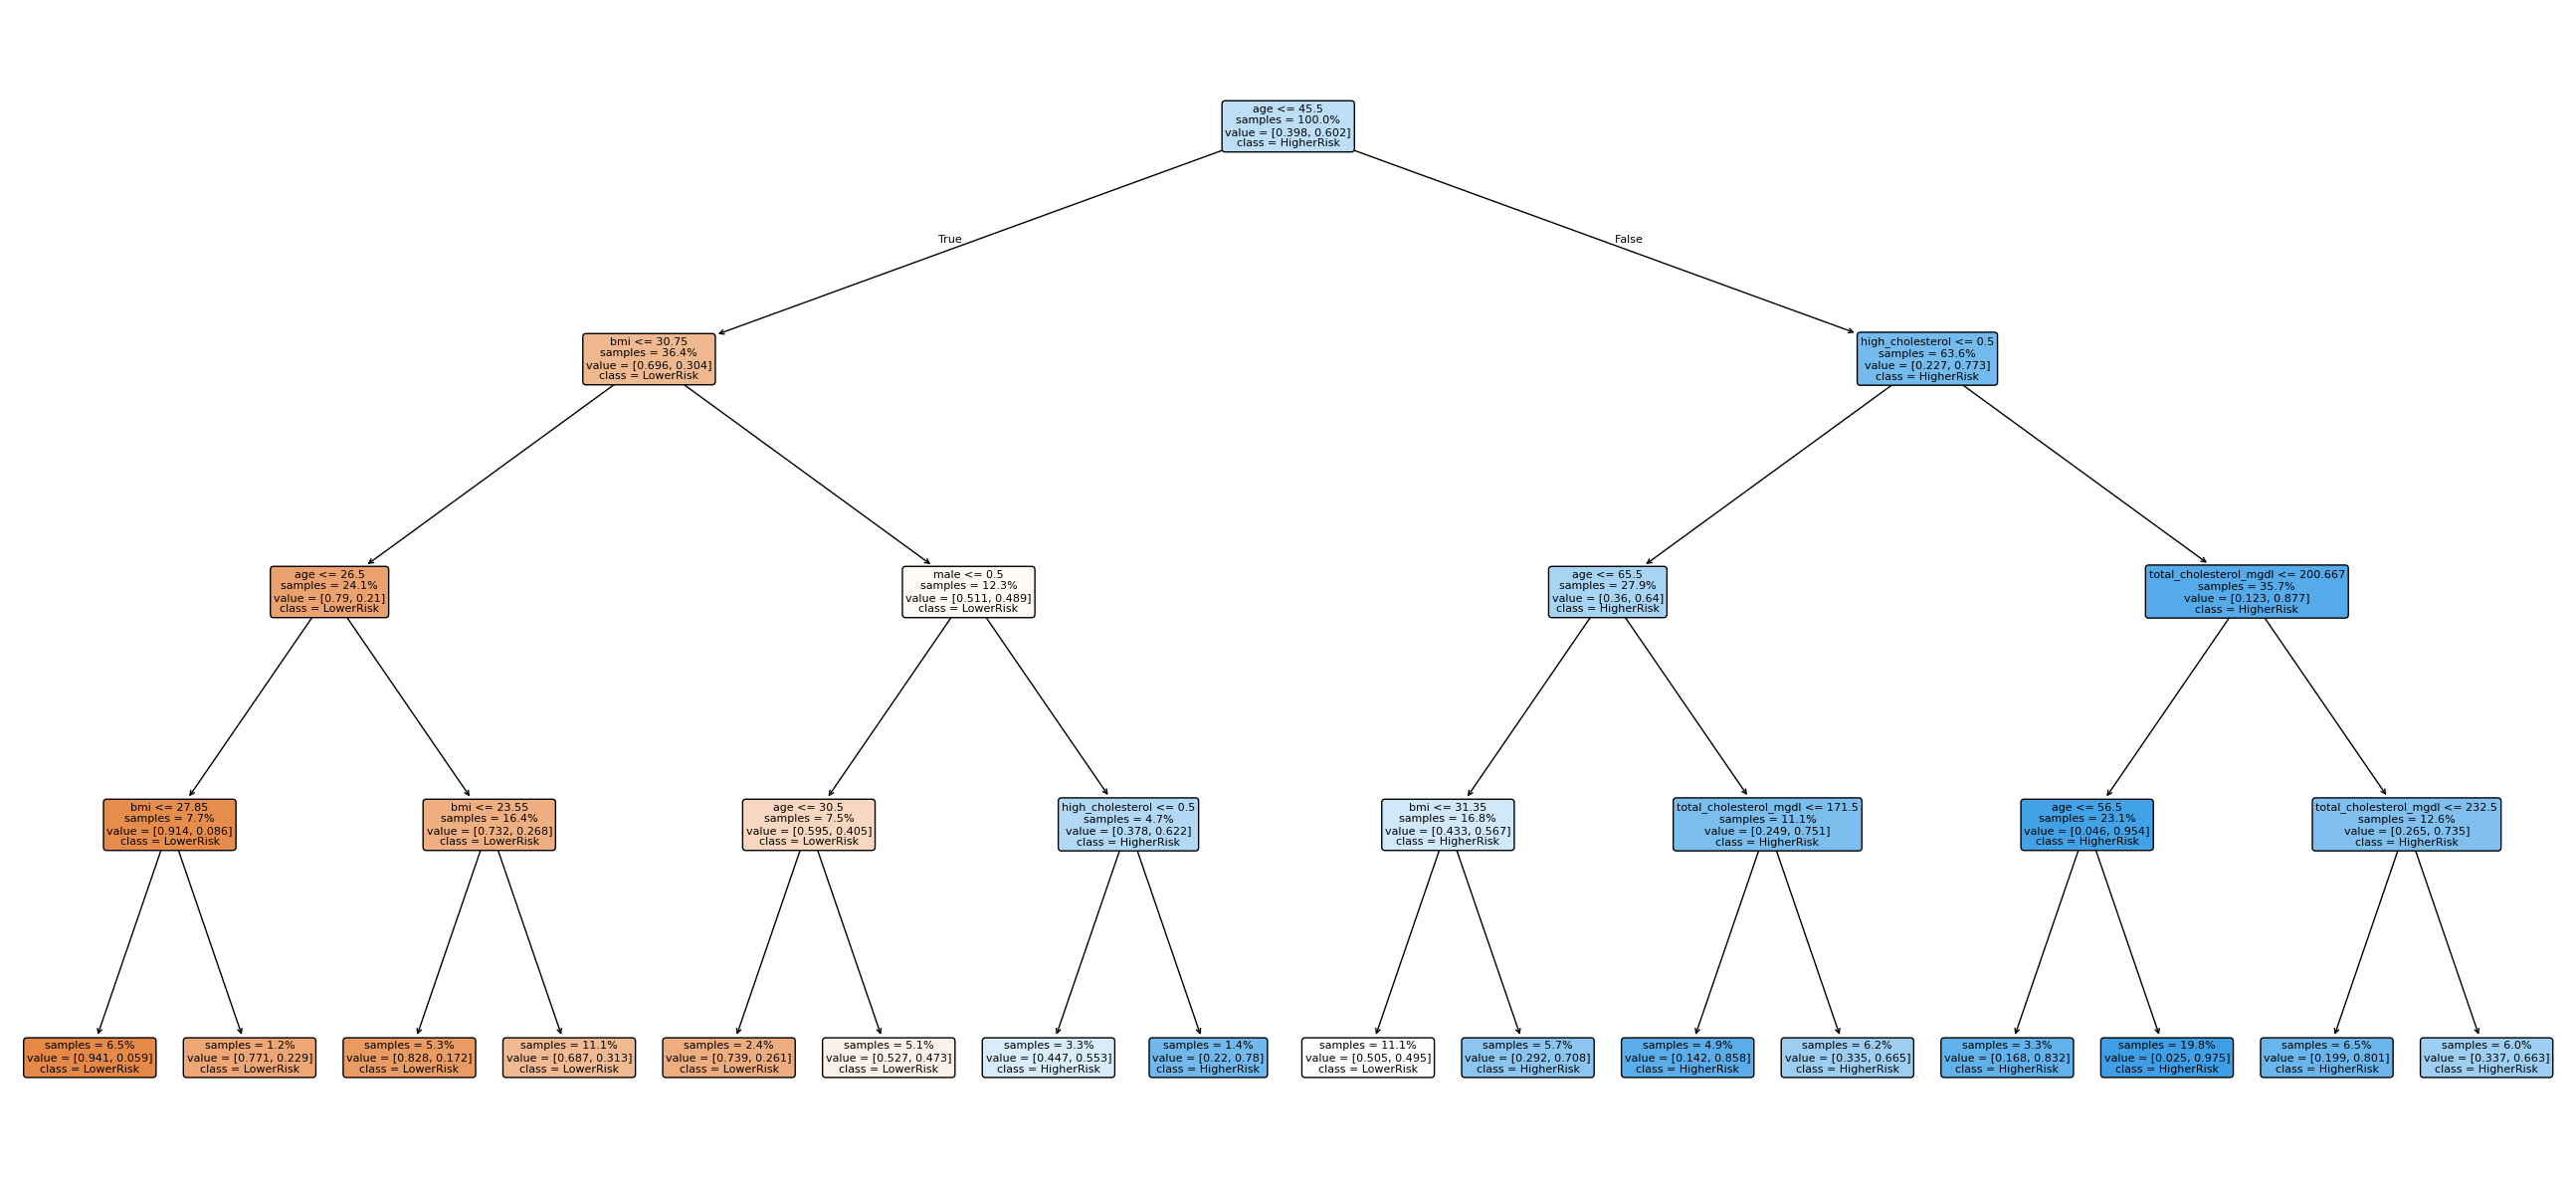

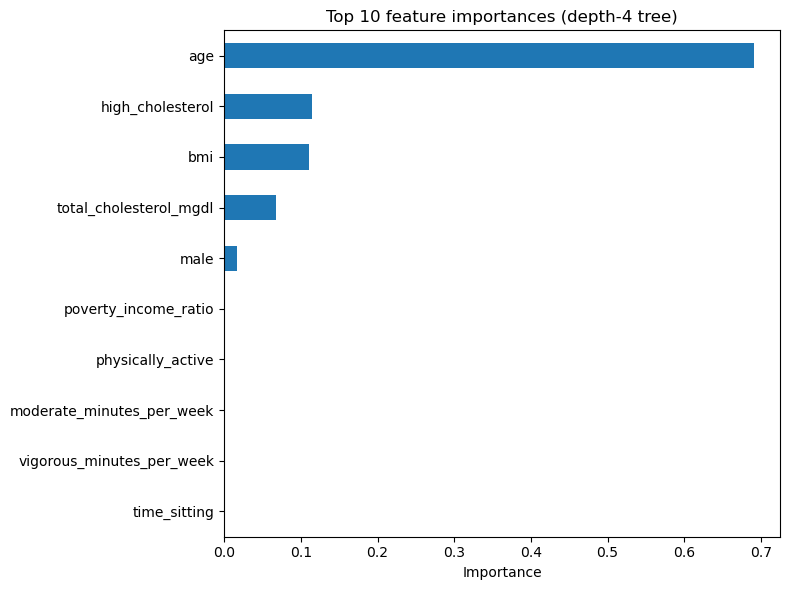

In [85]:
tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=30, random_state=42)
tree.fit(X_train, y_train)
 
pred = tree.predict(X_test)
print("=== Shallow interpretable tree (depth=4) ===")
print("Accuracy:", round(accuracy_score(y_test, pred), 3))
print(classification_report(y_test, pred, target_names=['Lower risk','Higher risk']))
 
# Feature importance ranking answers "which factor matters more"
imp = pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 10 feature importances:")
print(imp.head(10))
 
# Plot the tree
plt.figure(figsize=(26, 12))
plot_tree(tree, feature_names=X.columns, class_names=['LowerRisk','HigherRisk'],
          filled=True, rounded=True, fontsize=8, impurity=False, proportion=True)
plt.tight_layout()
plt.savefig(f'{output_dir}/tree_1.png', dpi=150)
plt.show()
plt.close()
 
# Plot feature importances
plt.figure(figsize=(8,6))
imp.head(10).iloc[::-1].plot(kind='barh')
plt.title('Top 10 feature importances (depth-4 tree)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(f'{output_dir}/tree_1_feature_importance.png', dpi=150)
plt.show()
plt.close()

Deeper Tree


=== Deeper tree (depth=8) ===
Accuracy: 0.734
              precision    recall  f1-score   support

  Lower risk       0.67      0.65      0.66       284
 Higher risk       0.77      0.79      0.78       429

    accuracy                           0.73       713
   macro avg       0.72      0.72      0.72       713
weighted avg       0.73      0.73      0.73       713


Top 10 feature importances (deeper tree):
age                         0.5193
bmi                         0.1259
high_cholesterol            0.0904
total_cholesterol_mgdl      0.0691
time_sitting                0.0291
male                        0.0216
avg_drinks_per_day          0.0212
drink_frequency_past_year   0.0182
moderate_minutes_per_week   0.0165
ever_smoker                 0.0164
dtype: float64


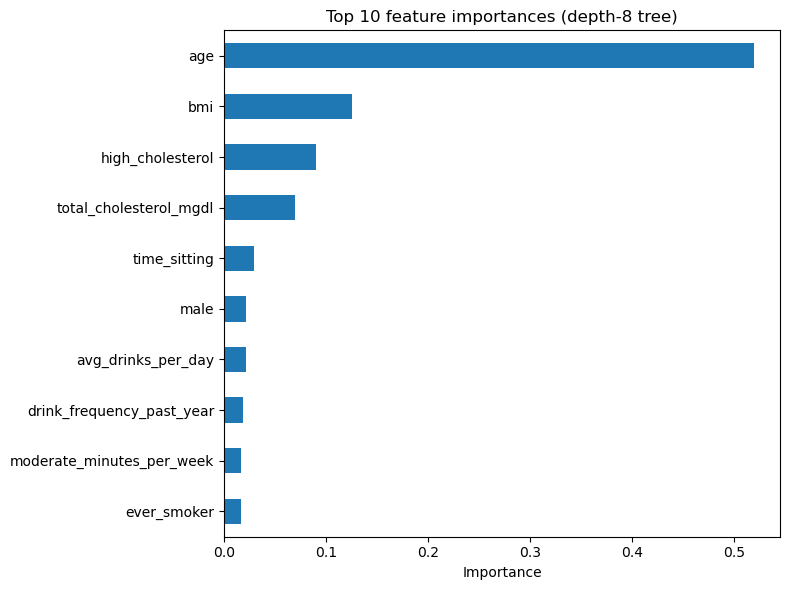

In [86]:
tree_deep = DecisionTreeClassifier(max_depth=8, min_samples_leaf=15, random_state=42)
tree_deep.fit(X_train, y_train)
pred_deep = tree_deep.predict(X_test)
print("\n=== Deeper tree (depth=8) ===")
print("Accuracy:", round(accuracy_score(y_test, pred_deep), 3))
print(classification_report(y_test, pred_deep, target_names=['Lower risk','Higher risk']))

 
imp_deep = pd.Series(tree_deep.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 10 feature importances (deeper tree):")
print(imp_deep.head(10))

# Plot feature importances
plt.figure(figsize=(8,6))
imp_deep.head(10).iloc[::-1].plot(kind='barh')
plt.title('Top 10 feature importances (depth-8 tree)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(f'{output_dir}/deep_tree_feature_importance.png', dpi=150)
plt.show()
plt.close()